# Topic and Theme Analysis
This notebook analyzes the papers from the hEART 2026 conference based on the generated `papers.json` file.

In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load the paper data
with open('public/data/papers.json', 'r') as f:
    data = json.load(f)

papers = data['papers']
df = pd.DataFrame(papers)
print(f"Loaded {len(df)} papers.")
df.head()

Loaded 231 papers.


,id,title,authors,presenter,abstract,keywords,date,time,sessionInterval,session,track,room,type,url,most_similar_ids,most_similar_scores,x,y
0,320869,To share or not to share? A Sequential SEM Ana...,"[Sarah Stelter, Sonja Haustein, Felix Wilhelm ...",Sarah Stelter,"Cooperative, Connected and Autonomous Mobility...","[Autonomous mobility, Behavioural Intention, C...",2026-09-29,10:15,10:15-12:45,"Session 8A: [Podium] Demand modelling, accessi...","Demand modelling, accessibility & activity pat...",Auditorium,Podium,https://easychair.org/smart-program/hEART2026/...,"[320889, 320854, 320901, 320780, 320974]","[0.1992412723291984, 0.11070107239266619, 0.10...",16.81,75.82
1,320974,Follow the e-riders: Exploring behaviour chang...,"[Alfredo Jose Ojeda Diaz, Emma-Sofie Hestbech,...",Alfredo Jose Ojeda Diaz,Promotion and assessment of sustainable and ac...,"[cycling behaviour, electric bikes, longitudin...",2026-09-29,10:45,10:15-12:45,"Session 8A: [Podium] Demand modelling, accessi...","Demand modelling, accessibility & activity pat...",Auditorium,Podium,https://easychair.org/smart-program/hEART2026/...,"[320997, 321000, 320901, 320780, 320875]","[0.14007395328018324, 0.10371370638311471, 0.0...",9.92,64.53
2,320875,Analysing modal shift and induced demand for i...,"[Behzad Bamdad Mehrabani, Willem Himpe, Juan B...",Behzad Bamdad Mehrabani,Innovative Air Mobility (IAM) is expected to e...,"[Demand Modelling, discrete choice modelling, ...",2026-09-29,11:15,10:15-12:45,"Session 8A: [Podium] Demand modelling, accessi...","Demand modelling, accessibility & activity pat...",Auditorium,Podium,https://easychair.org/smart-program/hEART2026/...,"[320854, 320974, 320796, 321007, 320785]","[0.09484048625798981, 0.0947846041235616, 0.08...",24.49,62.05
3,320776,Effects of Road and Other Mode Supply on Car Use,"[Maria Borjesson, Pernilla Ivehammar]",Maria Borjesson,This paper estimates how changes in road suppl...,"[Logsum, Non-car transport modes, Panel data, ...",2026-09-29,11:45,10:15-12:45,"Session 8A: [Podium] Demand modelling, accessi...","Demand modelling, accessibility & activity pat...",Auditorium,Podium,https://easychair.org/smart-program/hEART2026/...,"[321002, 320851, 320785, 320857, 320880]","[0.10026196349265633, 0.09866800687683171, 0.0...",23.27,61.61
4,320855,Perceived Mobility Need Satisfaction across Tr...,"[Stefan Bohmann, Eva Maria Kastl, Anja Kathari...",Stefan Bohmann,This study provides a first psychometric exami...,"[Confirmatory factor analysis, mobility behavi...",2026-09-29,12:15,10:15-12:45,"Session 8A: [Podium] Demand modelling, accessi...","Demand modelling, accessibility & activity pat...",Auditorium,Podium,https://easychair.org/smart-program/hEART2026/...,"[320844, 320932, 320936, 321006, 320814]","[0.08009849288942514, 0.07721528663161299, 0.0...",15.55,60.64


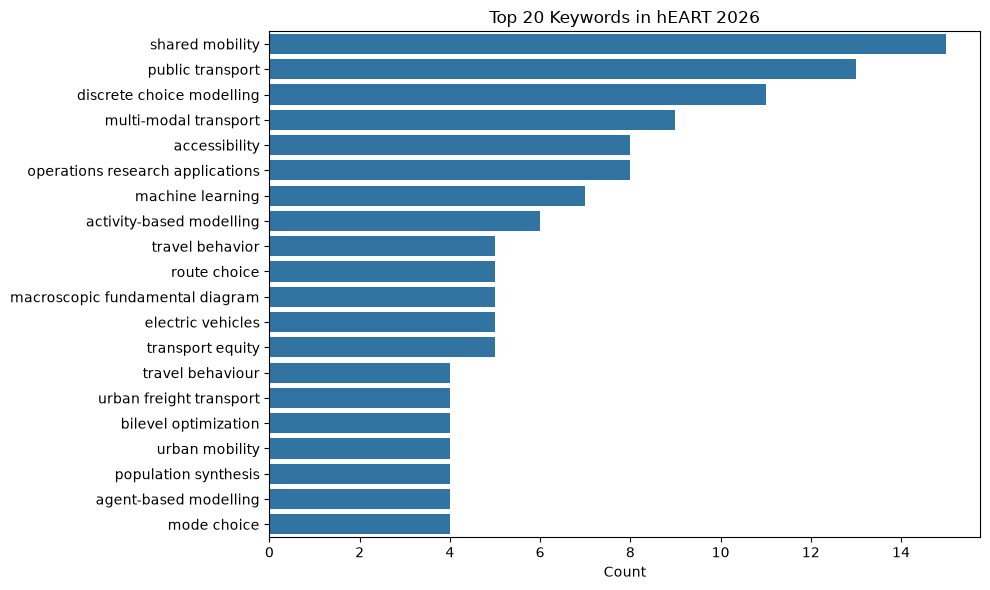

In [3]:
# 1. Explore Keywords and Themes
all_keywords = [kw.lower() for keywords in df['keywords'] for kw in keywords]
keyword_counts = Counter(all_keywords)

# Plot top 20 keywords
top_kws = keyword_counts.most_common(20)
plt.figure(figsize=(10, 6))
sns.barplot(x=[x[1] for x in top_kws], y=[x[0] for x in top_kws])
plt.title('Top 20 Keywords in hEART 2026')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

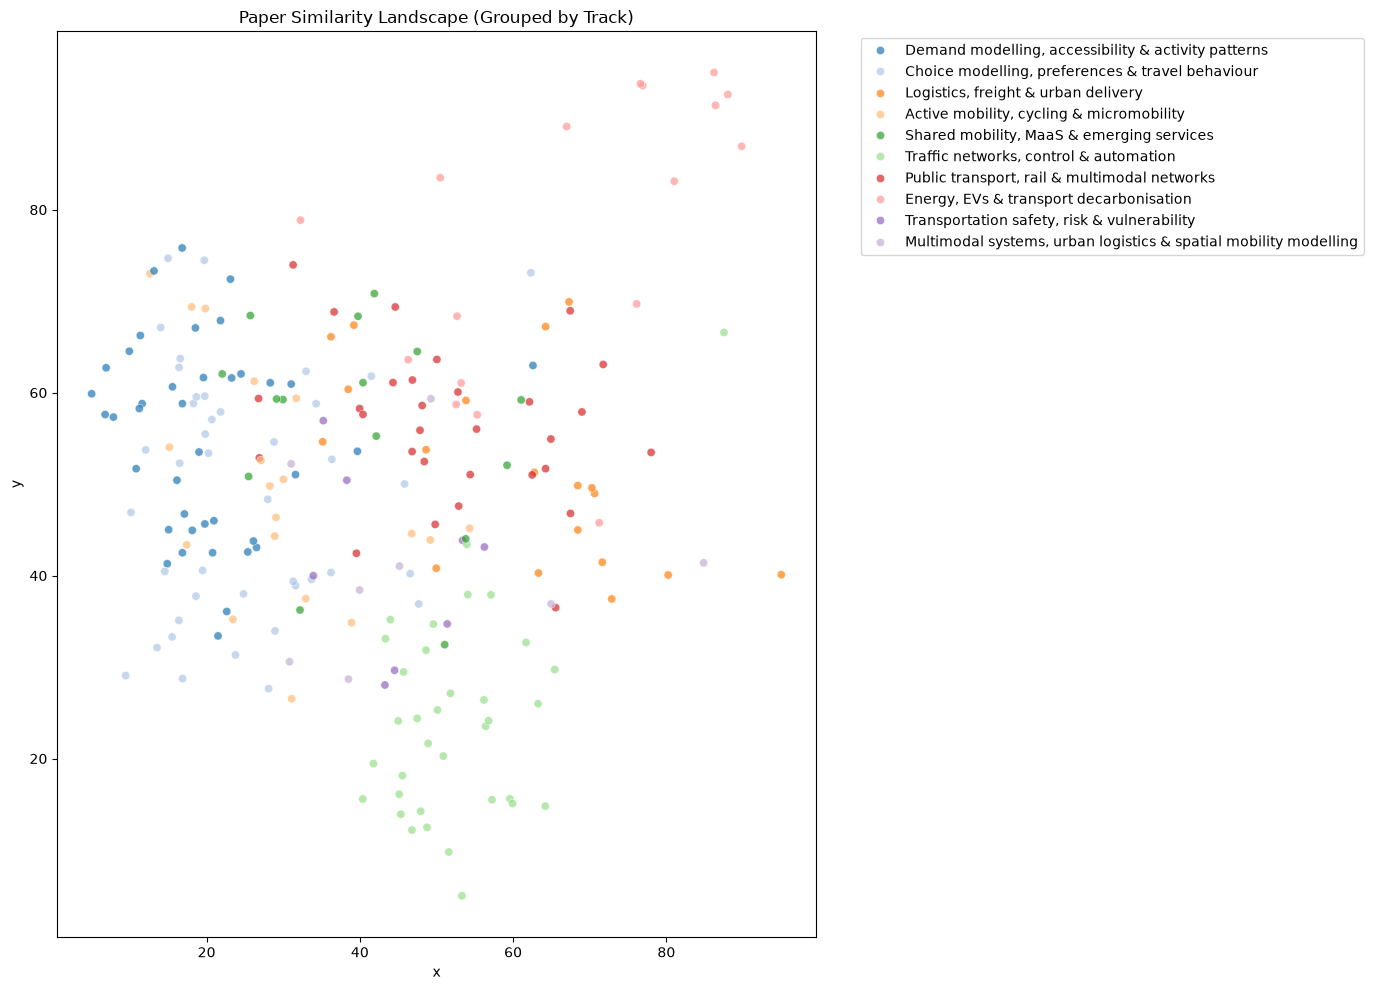

In [4]:
# 2. Exploring Topic Similarity Clusters
# The similarity script generates 'x' and 'y' coordinates using Eigenvectors.
# We can plot these to see how topics group together visually.
plt.figure(figsize=(14, 10))
sns.scatterplot(data=df, x='x', y='y', hue='track', alpha=0.7, palette='tab20')
plt.title('Paper Similarity Landscape (Grouped by Track)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [5]:

_title ='NextGen Assisted Utility Specification: Multitask Reinforcement Learning for Transfer Across Datasets'
df[df['title']==_title]

,id,title,authors,presenter,abstract,keywords,date,time,sessionInterval,session,track,room,type,url,most_similar_ids,most_similar_scores,x,y
80,320863,NextGen Assisted Utility Specification: Multit...,"[Gabriel Nova, Stephane Hess, Sander van Crane...",Gabriel Nova,Discrete choice model specification is a time-...,"[Artificial Intelligence, Assisted model speci...",2026-09-30,09:00,08:30-10:00,"Session 12B: [Podium] Choice modelling, prefer...","Choice modelling, preferences & travel behaviour",La salle 105,Podium,https://easychair.org/smart-program/hEART2026/...,"[320862, 320799, 320907, 320920, 320989]","[0.14322690072024424, 0.13225242784364039, 0.1...",15.5,33.3


In [6]:
# 3. Analyzing "Most Similar" Papers
# Let's look at a specific paper and see its closest neighbors based on your new weights
if 'most_similar_ids' in df.columns:
    sample_paper = df.iloc[80]
    
    print(f"Target Paper: {sample_paper['title']} (Track: {sample_paper['track']})\n")
    
    print("Most Similar Papers:")
    for sim_id, score in zip(sample_paper['most_similar_ids'], sample_paper['most_similar_scores']):
        match = df[df['id'] == sim_id]
        if not match.empty:
            print(f"- [Score: {score:.3f}] - track: {match.iloc[0]['track']} -> {match.iloc[0]['title']} ")


Target Paper: NextGen Assisted Utility Specification: Multitask Reinforcement Learning for Transfer Across Datasets (Track: Choice modelling, preferences & travel behaviour)

Most Similar Papers:
- [Score: 0.143] - track: Choice modelling, preferences & travel behaviour -> Symbolic Regression for Choice Models: An Interpretable Data-Driven Machine Learning for Discovering Utility Specifications 
- [Score: 0.132] - track: Traffic networks, control & automation -> Model Agnostic Meta-Learning for traffic assignment on disrupted networks 
- [Score: 0.122] - track: Choice modelling, preferences & travel behaviour -> Gradient-Assisted Model Specification 
- [Score: 0.114] - track: Shared mobility, MaaS & emerging services -> Joint Optimization of Pricing and Service Type in Ride-Hailing using Multi-agent Reinforcement Learning 
- [Score: 0.110] - track: Choice modelling, preferences & travel behaviour -> Variational Autoencoders for Anomaly Detection in Choice Models 


In [7]:
!python scripts/build_paper_data.py data/raw/heart29.html data/raw/heart30.html data/raw/heart01.html --keywords data/raw/heart_keywords.html

Wrote 231 papers to public/data/papers.json
